**BRFSS Risk Factors for Heart Disease Data EDA**

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Plot customization functions
def set_size_style(width, height, style=None):
    plt.figure(figsize=(width, height))
    if style != None:
        sns.set_style(style)

# Function for customizating the plot
def customize_plot(plot, title:str, xlabel:str,  ylabel:str, title_font:int, label_font:int):
    plot.set_title(title, fontsize = title_font, weight='bold')
    plot.set_xlabel(xlabel, fontsize = label_font, weight='bold')
    plot.set_ylabel(ylabel, fontsize = label_font, weight='bold')

In [80]:
BASE = "/content/drive/MyDrive/ECS 111 Group Project"

df = pd.read_csv(BASE + "/data/heart_BRFSS_no_nans.csv")

# print first entries
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [81]:
# number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 246022
Number of columns: 40


In [45]:
# print all column names
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# print names of columns and stats on each column
eda_table = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=False).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2)
})

eda_table = eda_table.sort_values("missing_percent", ascending=False)
eda_table.to_csv("eda_basics_table.csv", index=False)

1. State
2. Sex
3. GeneralHealth
4. PhysicalHealthDays
5. MentalHealthDays
6. LastCheckupTime
7. PhysicalActivities
8. SleepHours
9. RemovedTeeth
10. HadHeartAttack
11. HadAngina
12. HadStroke
13. HadAsthma
14. HadSkinCancer
15. HadCOPD
16. HadDepressiveDisorder
17. HadKidneyDisease
18. HadArthritis
19. HadDiabetes
20. DeafOrHardOfHearing
21. BlindOrVisionDifficulty
22. DifficultyConcentrating
23. DifficultyWalking
24. DifficultyDressingBathing
25. DifficultyErrands
26. SmokerStatus
27. ECigaretteUsage
28. ChestScan
29. RaceEthnicityCategory
30. AgeCategory
31. HeightInMeters
32. WeightInKilograms
33. BMI
34. AlcoholDrinkers
35. HIVTesting
36. FluVaxLast12
37. PneumoVaxEver
38. TetanusLast10Tdap
39. HighRiskLastYear
40. CovidPos


Useful column:   **HadHeartAttack**


In [12]:
eda_numerical_summary = df.describe()
eda_numerical_summary.to_csv(BASE + "eda_numerical_summary.csv", index=False)

In [48]:
for col in df.describe(include='object').columns:
    print('Column Name: ',col)
    print(df[col].unique())
    print('-'*50)

Column Name:  State
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']
--------------------------------------------------
Column Name:  Sex
['Female' 'Male']
--------------------------------------------------
Column Name:  GeneralHealth
['Very good' 'Fair' 'Good' 'Excellent' 'Poor']
--------------------------------------------------
Column Name:  LastCheckupTime
['Within past year (anytime less than 12 m

In [83]:
# Format AgeCategory ranges to be shorter

df['AgeCategory'].replace({'Age 80 or older' : '80+'}, inplace=True)

# Get unique values once to avoid issues if inplace=True modifies the underlying Series during iteration
unique_age_categories = df['AgeCategory'].unique()

for value in unique_age_categories:
    # Check if the value matches the 'Age X to Y' pattern
    # It should contain "Age", "to", and split into exactly 4 parts
    if 'Age' in value and 'to' in value:
        parts = value.split(' ')
        if len(parts) == 4:
            new_value = f"{parts[1]}-{parts[3]}"
            df['AgeCategory'].replace({value: new_value}, inplace=True)

df['AgeCategory'].unique()

/tmp/ipykernel_653/3564039080.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace({'Age 80 or older' : '80+'}, inplace=True)


array(['65-69', '70-74', '75-79', '80+', '50-54', '40-44', '60-64',
       '55-59', '45-49', '35-39', '25-29', '30-34', '18-24'], dtype=object)

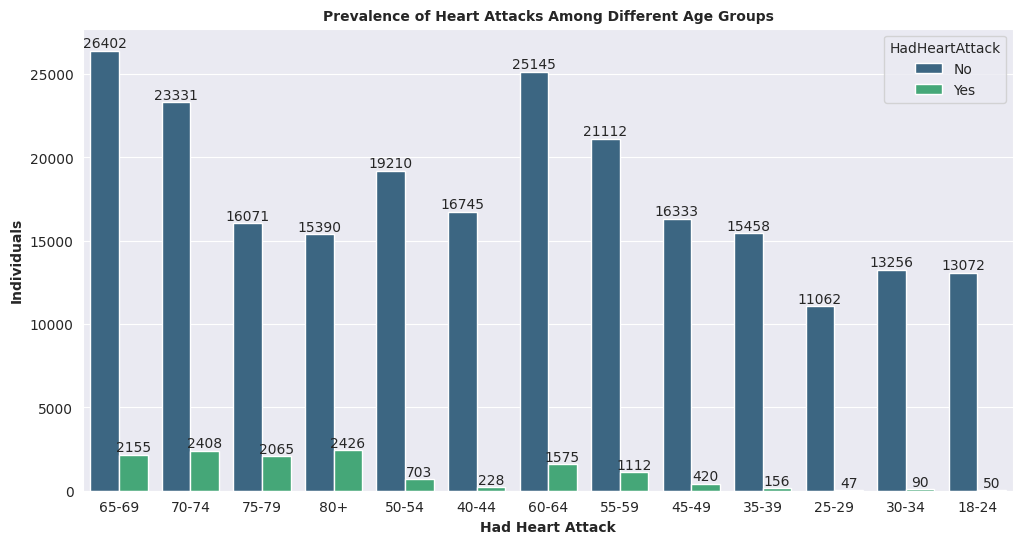

In [84]:
set_size_style(12,6,'darkgrid')
ax = sns.countplot(data = df, x = 'AgeCategory', hue = 'HadHeartAttack', palette='viridis')
customize_plot(ax,"Prevalence of Heart Attacks Among Different Age Groups","Had Heart Attack","Individuals",10,10)
for c in ax.containers:
    ax.bar_label(c)

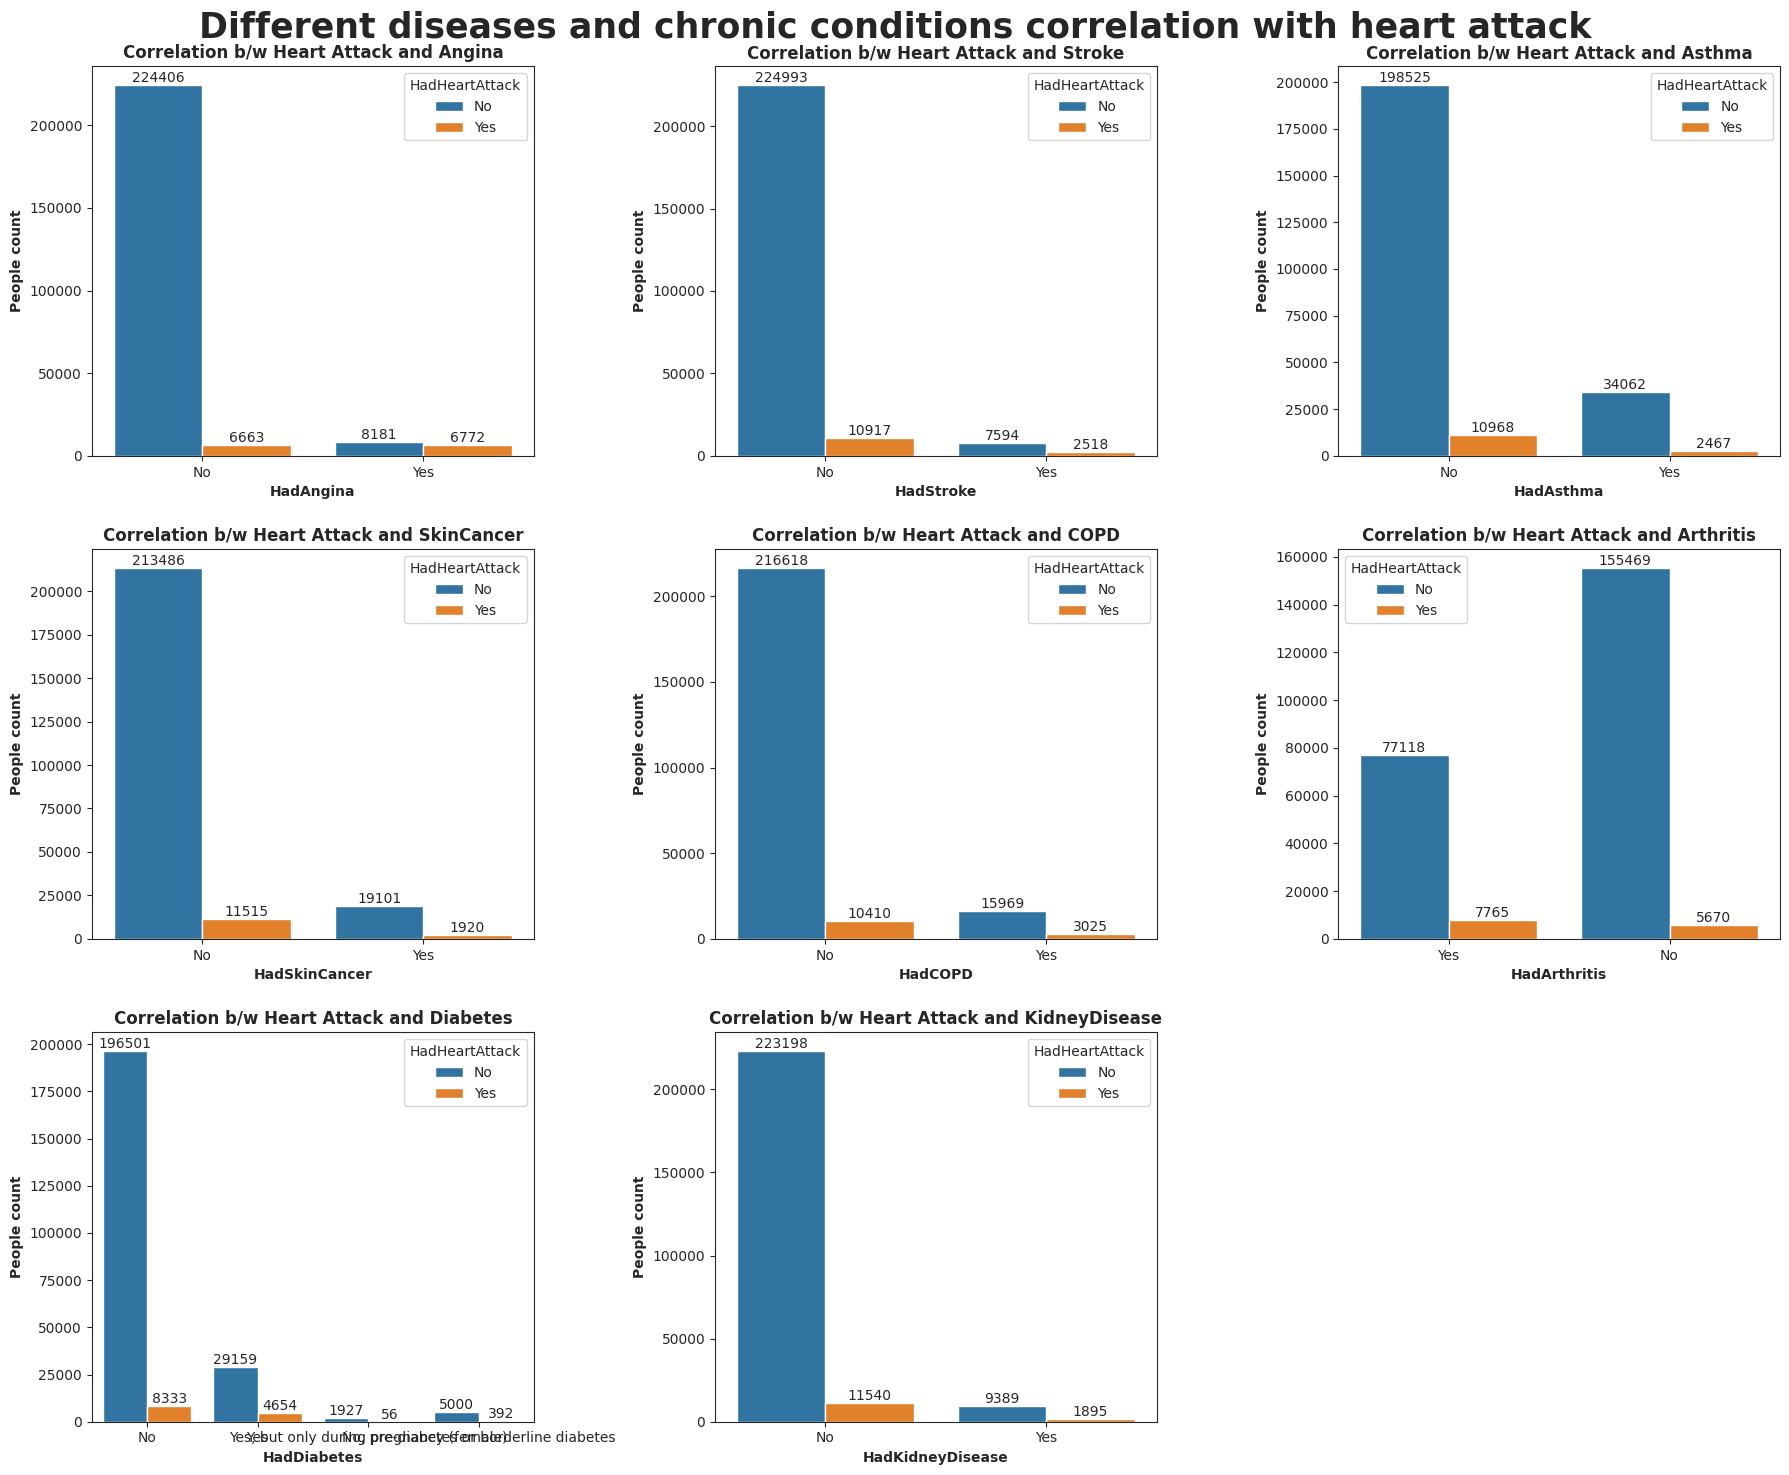

In [85]:
# Correlation between each chronic condition with heart disease status.

set_size_style(18,15,'ticks')
for i,column in enumerate(chronic_diseases.columns[2:],1):
    plt.subplot(3,3,i)
    # print(i,column)

    ax = sns.countplot(data=chronic_diseases, x=column, hue='HadHeartAttack')
    customize_plot(ax, 'Correlation b/w Heart Attack and '+column[3:] , column, 'People count', 12,10)

    # Annotating bar labels
    for container in ax.containers:
        ax.bar_label(container)
plt.suptitle('Different diseases and chronic conditions correlation with heart attack', size=25, fontweight='bold')
plt.tight_layout(w_pad=1, h_pad=2)

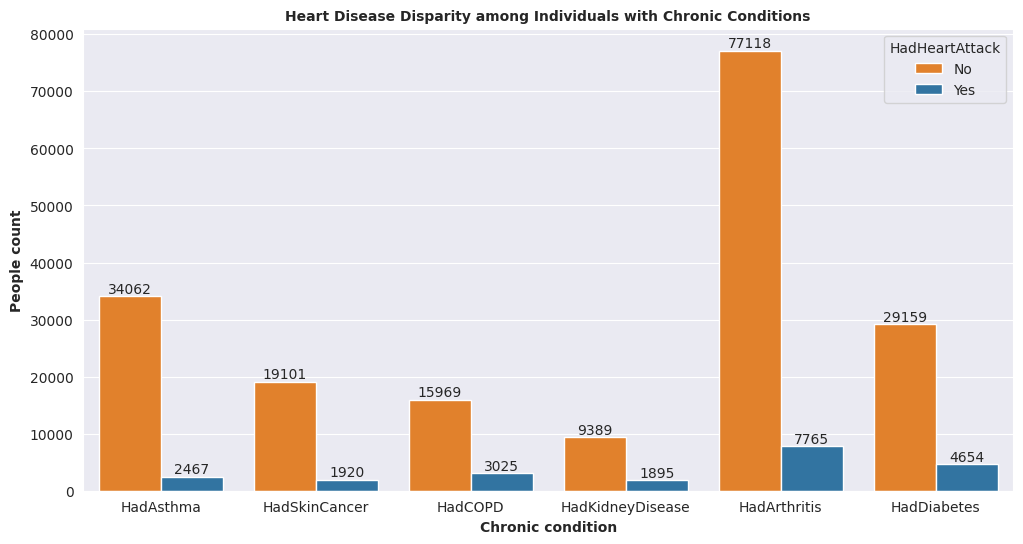

In [86]:
# How does the presence of these chronic conditions correlate with heart disease prevalence.

# First we will melt the dataframe, so that all diseases comes in one column and their status in another column
melted_df = chronic_diseases.melt(id_vars=['Sex', 'HadHeartAttack'], value_vars=['HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes'], var_name='Disease', value_name='Status')
melted_df

# Selecting all individuals with presence of diseases
individuals_with_diseases = melted_df[melted_df['Status'] == 'Yes']
individuals_with_diseases

# Plotting bar chart
set_size_style(12,6,'darkgrid')
ax= sns.countplot(data=individuals_with_diseases, x='Disease', hue='HadHeartAttack', palette=['tab:orange','tab:blue'])

customize_plot(ax, 'Heart Disease Disparity among Individuals with Chronic Conditions','Chronic condition' , 'People count', 10,10)

for container in ax.containers:
    ax.bar_label(container)

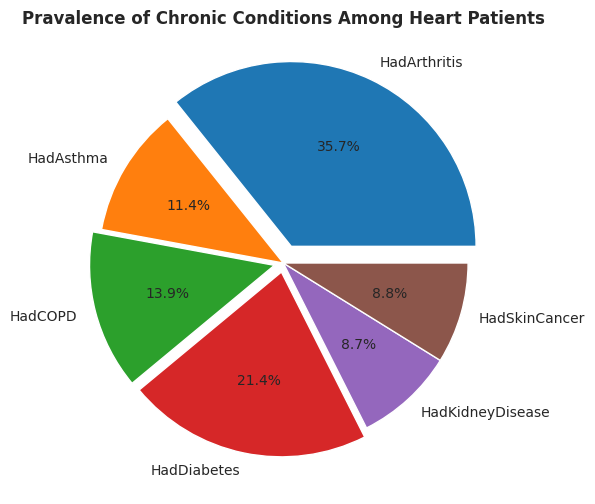

In [88]:
pivoted_df = individuals_with_diseases.pivot_table(values='Status',index='Disease', columns='HadHeartAttack', aggfunc='count')
pivoted_df

normalized_pivot = round(pivoted_df.div( pivoted_df.sum( axis=1 ) , axis=0 ), 2)
normalized_pivot

# Subsetting only "Yes" column from pivoted dataframe
has_heart_disease = pivoted_df['Yes']

# Plotting pie chart which shows share of chronic conditions
set_size_style(6,6)
ax = has_heart_disease.plot.pie(labels=has_heart_disease.index, autopct='%.1f%%' , explode=[0.1,0,0.05,0.05,0,0])
ax.set_title('Pravalence of Chronic Conditions Among Heart Patients', fontweight='bold')
ax.set_ylabel('')
# plt.legend()
plt.show()

###Arthiritis, diabetes, and COPD are more likely to have heart diseases as 35%, 21% and 14% respectively of them are also heart patients.

Text(0.5, 1.0, 'Prevalence of Health Behaviors among Heart Patients')

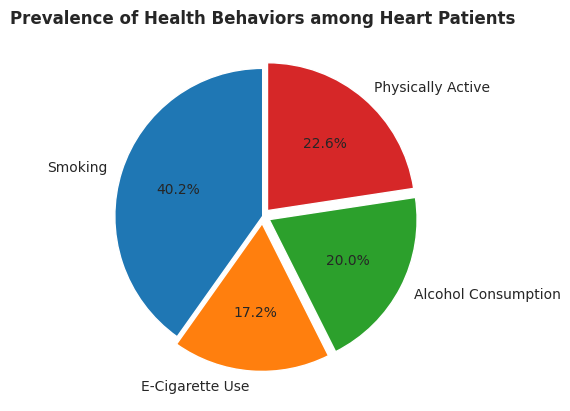

In [90]:
# Correlation between each behaviorial factor with heart disease status.

SmokerData = df[(df['SmokerStatus'] == 'Current smoker - now smokes every day') | (df['SmokerStatus'] == 'Current smoker - now smokes some days')]
ECigaretteData = df[(df['ECigaretteUsage'] == 'Use them every day') | (df['ECigaretteUsage'] == 'Use them some days')]
AlcoholDrinkersData = df[(df['AlcoholDrinkers'] == 'Yes')]
PhysicallyActiveData = df[(df['PhysicalActivities'] == 'Yes')]

Smoker_heart_attack_percentage = (SmokerData['HadHeartAttack'].value_counts(normalize=True) * 100).to_dict()
ECigarette_heart_attack_percentage = (ECigaretteData['HadHeartAttack'].value_counts(normalize=True) * 100).to_dict()
Alcohol_heart_attack_percentage = (AlcoholDrinkersData['HadHeartAttack'].value_counts(normalize=True) * 100).to_dict()
PhysicalActivities_heart_attack_percentage = (PhysicallyActiveData['HadHeartAttack'].value_counts(normalize=True) * 100).to_dict()


behavior_percentages = {
    'Smoking': Smoker_heart_attack_percentage.get('Yes'),
    'E-Cigarette Use': ECigarette_heart_attack_percentage.get('Yes'),
    'Alcohol Consumption': Alcohol_heart_attack_percentage.get('Yes'),
    'Physically Active': PhysicalActivities_heart_attack_percentage.get('Yes')
}
plt.pie(behavior_percentages.values(), labels=behavior_percentages.keys(), autopct='%1.1f%%', startangle=90,explode=[0,0.05,0.05,0.05])
plt.title('Prevalence of Health Behaviors among Heart Patients', weight = 'bold')

###Those who have smoked are at higher risk of experiencing a heart attack

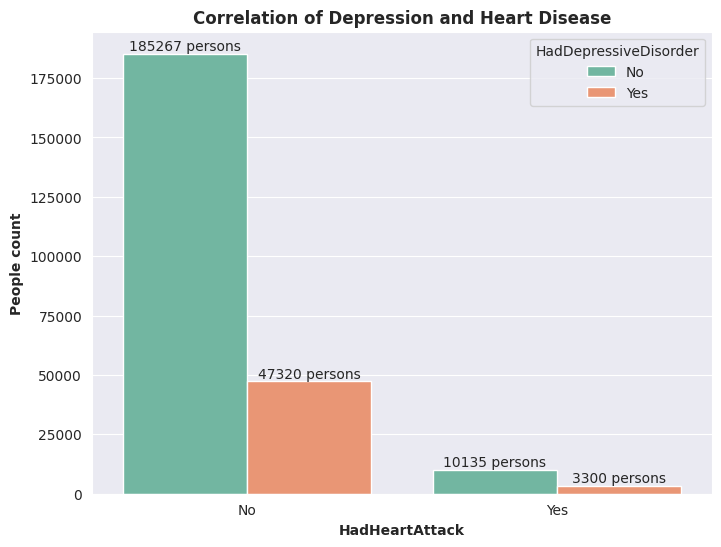

In [94]:
# Effect of mental health on heart

mental_health_cols = df[['GeneralHealth', 'HadHeartAttack', 'HadDepressiveDisorder', 'MentalHealthDays']]
mental_health_cols

set_size_style(8,6,'darkgrid')
ax = sns.countplot(data=mental_health_cols, x='HadHeartAttack', hue='HadDepressiveDisorder', palette='Set2')
customize_plot(ax,'Correlation of Depression and Heart Disease', 'HadHeartAttack', 'People count', 12, 10)

for container in ax.containers:
    ax.bar_label(container, fmt='%g persons')

In [91]:
# function that for each feature calulates the percentage of people in each category that have heart disease
def heart_disease_rate_by_feature(data, feature, target="HadHeartAttack"):
    if feature not in data.columns:
        raise ValueError(f"{feature} is not in the dataframe columns.")

    if target not in data.columns:
        raise ValueError(f"{target} is not in the dataframe columns.")

    temp = data[[feature, target]].copy()
    temp = temp[temp[target].isin([1, 2])]
    temp = temp.dropna(subset=[feature])

    summary = (
        temp
        .groupby(feature)
        .agg(
            total_people=(target, "count"),
            heart_disease_cases=(target, lambda x: (x == 1).sum())
        )
        .reset_index()
    )

    summary["heart_disease_percent"] = (
        summary["heart_disease_cases"] / summary["total_people"] * 100
    ).round(2)

    summary = summary.rename(columns={feature: "feature_value"})

    summary.insert(0, "feature", feature)

    summary = summary.sort_values(
        "heart_disease_percent",
        ascending=False
    )

    return summary

# **Which features impact heart disease the most?**

In [97]:
all_heart_patients = df[df['HadHeartAttack'] == 'Yes']
all_heart_patients = all_heart_patients.drop(columns=['HadHeartAttack'])

for column in all_heart_patients.columns[4:]:
    print(all_heart_patients[column].value_counts(), end='\n\n')

MentalHealthDays
0.0     8610
30.0    1226
2.0      514
15.0     465
5.0      450
10.0     436
3.0      358
1.0      319
20.0     274
4.0      188
7.0      153
25.0      90
14.0      63
8.0       59
6.0       54
12.0      37
28.0      34
29.0      24
21.0      17
18.0      13
27.0      11
16.0       8
11.0       6
22.0       6
17.0       5
26.0       4
24.0       4
19.0       2
9.0        2
13.0       2
23.0       1
Name: count, dtype: int64

LastCheckupTime
Within past year (anytime less than 12 months ago)         12386
Within past 2 years (1 year but less than 2 years ago)       585
Within past 5 years (2 years but less than 5 years ago)      273
5 or more years ago                                          191
Name: count, dtype: int64

PhysicalActivities
Yes    8514
No     4921
Name: count, dtype: int64

SleepHours
8.0     3815
7.0     2926
6.0     2831
5.0     1116
9.0      797
4.0      695
10.0     593
3.0      193
12.0     190
2.0       91
1.0       43
11.0      38
16.0      24


**Variables that would be useful to include:**   

*   Having Angina pain.
*   Having Depressive Disorder
*   Smoking
*   Removed Teeth
*   Difficult Walking
*   Age 60+
*   Having Arthritis.
*   Having Diabetes.
*   Lack of physical activity.